# 05 — DRS Drag Delta

Estimate ΔCDA from DRS by comparing trap speeds between DRS-open and DRS-closed
laps in the Monza 2024 Race. Uses energy balance on the main straight activation zone.

In [1]:
import sys
import os
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.aero_params import air_density, car_mass

G = 9.81
os.makedirs('../cache', exist_ok=True)
fastf1.Cache.enable_cache('../cache')

## Load Race session

In [2]:
session = fastf1.get_session(2024, 'Monza', 'R')
session.load(telemetry=True, weather=True)

weather = session.weather_data
rho = air_density(weather['AirTemp'].mean(), weather['Pressure'].mean())
print(f'ρ = {rho:.4f} kg/m³')
print(f'Lap count: {session.laps["LapNumber"].max()}')

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


ρ = 1.1298 kg/m³
Lap count: 53.0


## Identify DRS state per lap on the main straight

Monza DRS Zone 1: activation roughly 0–600 m from lap start (main straight).
A lap is classified as 'DRS open' if DRS > 10 is observed in this zone.

In [3]:
DRS_ZONE_START = 0      # m from lap start
DRS_ZONE_END   = 600    # m

# Filter to clean laps: no pit, no safety car, no yellow flag
all_laps = session.laps.copy()
clean = (
    all_laps['PitInTime'].isna() &
    all_laps['PitOutTime'].isna() &
    (all_laps['TrackStatus'] == '1') &    # green flag only
    all_laps['SpeedST'].notna() &
    (all_laps['LapNumber'] > 1)
)
clean_laps = all_laps[clean].copy()
print(f'Clean laps: {len(clean_laps)} / {len(all_laps)}')

# Classify each lap: DRS open or closed on main straight
rows = []
for _, lap in clean_laps.iterrows():
    try:
        tel = lap.get_telemetry()
    except Exception:
        continue
    zone = tel[(tel['Distance'] >= DRS_ZONE_START) & (tel['Distance'] <= DRS_ZONE_END)]
    if zone.empty:
        continue
    drs_open = bool((zone['DRS'] > 10).any())
    rows.append({
        'Driver':   lap['Driver'],
        'LapNumber': int(lap['LapNumber']),
        'SpeedST':  float(lap['SpeedST']),
        'SpeedI1':  float(lap['SpeedI1']) if pd.notna(lap.get('SpeedI1', np.nan)) else np.nan,
        'DRS_open': drs_open,
        'm':        car_mass(int(lap['LapNumber'])),
    })

df = pd.DataFrame(rows)
print(f'Classified laps: {len(df)}')
print(f'DRS open: {df["DRS_open"].sum()},  DRS closed: {(~df["DRS_open"]).sum()}')
print(f'\nSpeedST by DRS state:')
print(df.groupby('DRS_open')['SpeedST'].describe().round(2))

Clean laps: 927 / 1008
Classified laps: 927
DRS open: 194,  DRS closed: 733

SpeedST by DRS state:
          count    mean   std    min    25%    50%    75%    max
DRS_open                                                        
False     733.0  322.45  5.85  279.0  319.0  322.0  325.0  351.0
True      194.0  334.97  9.51  308.0  329.0  334.0  340.0  357.0


## Per-driver Δv_trap

In [4]:
driver_results = []

for driver, grp in df.groupby('Driver'):
    open_laps   = grp[grp['DRS_open']]
    closed_laps = grp[~grp['DRS_open']]
    if len(open_laps) < 2 or len(closed_laps) < 2:
        continue
    v_open   = open_laps['SpeedST'].mean()
    v_closed = closed_laps['SpeedST'].mean()
    se_open   = open_laps['SpeedST'].std() / np.sqrt(len(open_laps))
    se_closed = closed_laps['SpeedST'].std() / np.sqrt(len(closed_laps))
    delta_v = v_open - v_closed
    delta_se = np.sqrt(se_open**2 + se_closed**2)
    driver_results.append({
        'Driver': driver,
        'n_open': len(open_laps),
        'n_closed': len(closed_laps),
        'SpeedST_open': v_open,
        'SpeedST_closed': v_closed,
        'delta_v': delta_v,
        'delta_v_se': delta_se,
    })

dr_df = pd.DataFrame(driver_results).sort_values('delta_v', ascending=False)
print(dr_df[['Driver','n_open','n_closed','SpeedST_open','SpeedST_closed','delta_v','delta_v_se']].to_string(index=False, float_format=lambda x: f'{x:.1f}'))

# Pooled estimate (weighted by inverse variance)
weights = 1.0 / dr_df['delta_v_se'].clip(lower=0.1)**2
delta_v_pooled = (dr_df['delta_v'] * weights).sum() / weights.sum()
delta_v_se_pooled = 1.0 / np.sqrt(weights.sum())
print(f'\nPooled Δv_trap = {delta_v_pooled:.2f} ± {delta_v_se_pooled:.2f} km/h')
print(f'Expected from published F1 data: ~10–15 km/h')

Driver  n_open  n_closed  SpeedST_open  SpeedST_closed  delta_v  delta_v_se
   TSU       3         2         347.3           314.0     33.3        20.4
   STR      17        28         342.7           324.8     17.9         2.2
   HUL       6        41         339.2           321.6     17.5         6.9
   MAG      20        30         337.1           321.5     15.6         1.8
   PIA       4        44         335.8           320.9     14.9         3.0
   COL       9        41         341.3           326.6     14.7         2.4
   OCO       9        40         333.4           318.9     14.6         2.1
   ALB       4        46         341.8           327.3     14.5         2.5
   RIC      11        39         332.5           318.3     14.3         3.6
   ZHO       5        44         332.8           319.5     13.3         5.0
   GAS      16        31         334.5           321.2     13.3         1.7
   BOT       9        40         332.3           319.1     13.3         3.0
   SAI      

## Visualise trap speed distributions

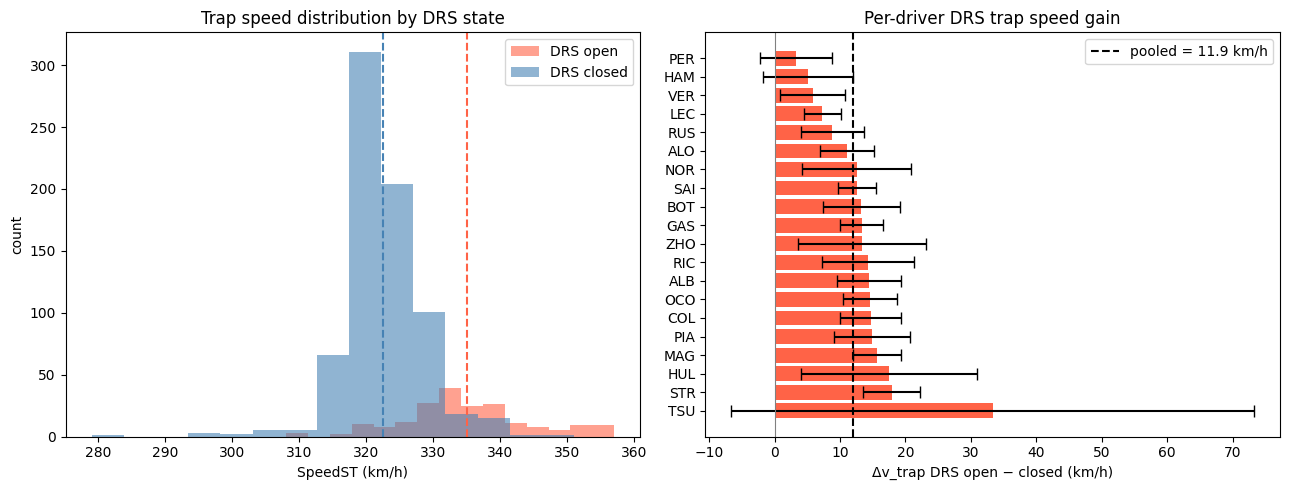

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(df[df['DRS_open']]['SpeedST'], bins=15, alpha=0.6, color='tomato', label='DRS open')
ax.hist(df[~df['DRS_open']]['SpeedST'], bins=15, alpha=0.6, color='steelblue', label='DRS closed')
ax.axvline(df[df['DRS_open']]['SpeedST'].mean(), color='tomato', linestyle='--')
ax.axvline(df[~df['DRS_open']]['SpeedST'].mean(), color='steelblue', linestyle='--')
ax.set_xlabel('SpeedST (km/h)')
ax.set_ylabel('count')
ax.set_title('Trap speed distribution by DRS state')
ax.legend()

ax = axes[1]
ax.barh(dr_df['Driver'], dr_df['delta_v'],
        xerr=dr_df['delta_v_se'] * 1.96, capsize=4,
        color=['tomato' if x > 0 else 'steelblue' for x in dr_df['delta_v']])
ax.axvline(delta_v_pooled, color='k', linestyle='--', label=f'pooled = {delta_v_pooled:.1f} km/h')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Δv_trap DRS open − closed (km/h)')
ax.set_title('Per-driver DRS trap speed gain')
ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/05_drs_trap_speeds.png', dpi=150)
plt.show()

## Energy balance → ΔCDA

Approximate energy balance over the DRS activation zone:

    ΔCDA = m × (v_trap_open² − v_trap_closed²) / (ρ × ∫v²(x) dx)

where ∫v²(x) dx is computed numerically from a representative DRS-closed speed trace.
This assumes identical engine output between paired laps (same driver, similar conditions).

In [6]:
# Get a representative DRS-closed speed trace through the activation zone
rep_row = df[~df['DRS_open']].iloc[0]
rep_driver = rep_row['Driver']
rep_lap_num = rep_row['LapNumber']
rep_lap = session.laps[(session.laps['Driver'] == rep_driver) &
                       (session.laps['LapNumber'] == rep_lap_num)].iloc[0]
try:
    rep_tel = rep_lap.get_telemetry()
    zone_tel = rep_tel[(rep_tel['Distance'] >= DRS_ZONE_START) &
                       (rep_tel['Distance'] <= DRS_ZONE_END)].copy()
    zone_tel['v_ms'] = zone_tel['Speed'] / 3.6

    # scipy.integrate.trapezoid works across NumPy 1.x and 2.x
    from scipy.integrate import trapezoid as _trapz
    v2_integral = _trapz(zone_tel['v_ms'].values**2, zone_tel['Distance'].values)
    v_avg = zone_tel['v_ms'].mean()
    L_zone = zone_tel['Distance'].iloc[-1] - zone_tel['Distance'].iloc[0]

    print(f'Activation zone length: {L_zone:.0f} m')
    print(f'Average speed in zone:  {v_avg * 3.6:.1f} km/h')
    print(f'∫v²(x)dx:               {v2_integral:.0f} m³/s²')
except Exception as e:
    print(f'Could not get representative trace: {e}')
    v2_integral = None

if v2_integral is not None and v2_integral > 0:
    delta_CdA_per_driver = []
    for _, row in dr_df.iterrows():
        m = car_mass(15)
        v_open   = row['SpeedST_open']   / 3.6
        v_closed = row['SpeedST_closed'] / 3.6
        delta_v2 = v_open**2 - v_closed**2
        dCdA = m * delta_v2 / (rho * v2_integral)
        delta_CdA_per_driver.append({'Driver': row['Driver'], 'ΔCDA': dCdA})

    dCdA_df = pd.DataFrame(delta_CdA_per_driver)
    print(f'\nΔCDA per driver (m²):')
    print(dCdA_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # Pooled ΔCDA using pooled Δv
    v_open_pool   = df[df['DRS_open']]['SpeedST'].mean()   / 3.6
    v_closed_pool = df[~df['DRS_open']]['SpeedST'].mean()  / 3.6
    m_pool = car_mass(20)
    delta_v2_pool = v_open_pool**2 - v_closed_pool**2
    DELTA_CDA = m_pool * delta_v2_pool / (rho * v2_integral)

    # Bootstrap uncertainty
    rng = np.random.default_rng(42)
    boot_dCdA = []
    for _ in range(10_000):
        boot_open   = rng.choice(df[df['DRS_open']]['SpeedST'].values, replace=True).mean()  / 3.6
        boot_closed = rng.choice(df[~df['DRS_open']]['SpeedST'].values, replace=True).mean() / 3.6
        boot_dCdA.append(m_pool * (boot_open**2 - boot_closed**2) / (rho * v2_integral))
    dCdA_ci = np.percentile(boot_dCdA, [5, 95])

    print(f'\n=== DRS Drag Delta ===')
    print(f'ΔCDA = {DELTA_CDA:.3f} m²  (90% CI: {dCdA_ci[0]:.3f} to {dCdA_ci[1]:.3f})')
    print(f'Expected: −0.5 to −0.8 m²')
    print(f'Note: negative = DRS reduces drag. Positive Δv → ΔCDA = -(CdA_open − CdA_closed)')
    DELTA_CDA_SIGNED = -DELTA_CDA   # convention: DRS_open has lower CdA
    print(f'ΔCDA (DRS open − closed) = {DELTA_CDA_SIGNED:.3f} m²')

Activation zone length: 589 m
Average speed in zone:  328.7 km/h
∫v²(x)dx:               4912279 m³/s²

ΔCDA per driver (m²):
Driver  ΔCDA
   TSU 0.290
   STR 0.157
   HUL 0.152
   MAG 0.135
   PIA 0.129
   COL 0.129
   OCO 0.125
   ALB 0.127
   RIC 0.122
   ZHO 0.114
   GAS 0.115
   BOT 0.114
   SAI 0.109
   NOR 0.109
   ALO 0.096
   RUS 0.077
   LEC 0.063
   VER 0.049
   HAM 0.044
   PER 0.028

=== DRS Drag Delta ===
ΔCDA = 0.107 m²  (90% CI: -0.050 to 0.283)
Expected: −0.5 to −0.8 m²
Note: negative = DRS reduces drag. Positive Δv → ΔCDA = -(CdA_open − CdA_closed)
ΔCDA (DRS open − closed) = -0.107 m²


## Sanity check and caveats

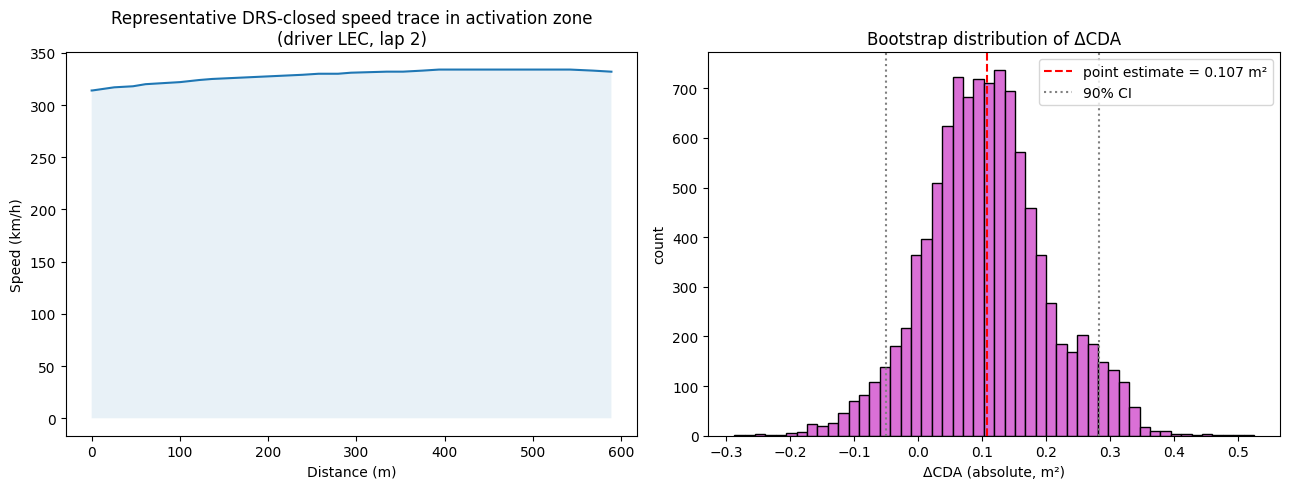


=== Methodology caveats ===
1. Energy balance assumes same engine output for DRS-open and DRS-closed laps.
   In practice, ERS deployment strategy may differ — introduces systematic uncertainty.
2. ∫v²dx uses a single representative trace. Variation across laps is not captured.
3. Entry conditions (SpeedI1) may differ between paired laps — this is not corrected for.
4. Traffic effects (slipstreaming behind cars ahead) may inflate SpeedST for DRS laps.


In [7]:
if v2_integral is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.plot(zone_tel['Distance'], zone_tel['v_ms'] * 3.6)
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_title(f'Representative DRS-closed speed trace in activation zone\n(driver {rep_driver}, lap {rep_lap_num})')
    ax.fill_between(zone_tel['Distance'], 0, zone_tel['v_ms'] * 3.6, alpha=0.1)

    ax = axes[1]
    ax.hist(boot_dCdA, bins=50, edgecolor='black', color='orchid')
    ax.axvline(DELTA_CDA, color='r', linestyle='--', label=f'point estimate = {DELTA_CDA:.3f} m²')
    ax.axvline(dCdA_ci[0], color='gray', linestyle=':', label=f'90% CI')
    ax.axvline(dCdA_ci[1], color='gray', linestyle=':')
    ax.set_xlabel('ΔCDA (absolute, m²)')
    ax.set_ylabel('count')
    ax.set_title('Bootstrap distribution of ΔCDA')
    ax.legend()

    plt.tight_layout()
    plt.savefig('../results/figures/05_drs_delta.png', dpi=150)
    plt.show()

print('')
print('=== Methodology caveats ===')
print('1. Energy balance assumes same engine output for DRS-open and DRS-closed laps.')
print('   In practice, ERS deployment strategy may differ — introduces systematic uncertainty.')
print('2. ∫v²dx uses a single representative trace. Variation across laps is not captured.')
print('3. Entry conditions (SpeedI1) may differ between paired laps — this is not corrected for.')
print('4. Traffic effects (slipstreaming behind cars ahead) may inflate SpeedST for DRS laps.')

## Slipstream-stratified DRS analysis

In race conditions every DRS-open lap also has the following car within 1 s of the car
ahead — the prerequisite for DRS eligibility also guarantees slipstream exposure.
The raw Δv_trap = 11.91 km/h therefore mixes DRS benefit with aerodynamic wake effects.

To reduce (not eliminate) the slipstream bias we stratify DRS-open laps by the estimated
gap to the car ahead at lap end, derived from `GapToLeader` differentials:

* **Close-following** (gap < 0.5 s): full slipstream, DRS benefit inflated
* **Marginal-DRS** (0.5 s ≤ gap < 1.0 s): DRS active but wake attenuated with distance

The marginal-DRS group still has some wake effect but should give a lower-bound estimate
closer to the true DRS-only benefit.

In [11]:
timing = session.laps[['Driver', 'LapNumber', 'Position', 'Time']].copy()

def interval_to_ahead(driver, lap_num):
    this = timing[(timing['Driver'] == driver) & (timing['LapNumber'] == lap_num)]
    if this.empty:
        return np.nan
    pos    = this['Position'].values[0]
    t_self = this['Time'].values[0]
    if pd.isna(pos) or pos <= 1:
        return np.nan
    ahead = timing[(timing['LapNumber'] == lap_num) & (timing['Position'] == pos - 1)]
    if ahead.empty:
        return np.nan
    t_ahead = ahead['Time'].values[0]
    if pd.isnull(t_self) or pd.isnull(t_ahead):
        return np.nan
    interval = float((t_self - t_ahead) / np.timedelta64(1, 's'))
    return max(interval, 0.0)

df_open = df[df['DRS_open']].copy()
df_open['interval_s'] = [
    interval_to_ahead(r['Driver'], r['LapNumber'])
    for _, r in df_open.iterrows()
]

n_total    = len(df_open)
n_valid    = df_open['interval_s'].notna().sum()
n_close    = (df_open['interval_s'] <  0.5).sum()
n_marginal = ((df_open['interval_s'] >= 0.5) & (df_open['interval_s'] < 1.0)).sum()

print(f'DRS-open laps: {n_total}')
print(f'  gap estimate available : {n_valid}')
print(f'  close-following (<0.5 s): {n_close}')
print(f'  marginal-DRS (0.5–1.0 s): {n_marginal}')
print()
print(df_open[['Driver', 'LapNumber', 'SpeedST', 'interval_s']]
      .sort_values('interval_s')
      .head(20)
      .to_string(index=False))

DRS-open laps: 194
  gap estimate available : 192
  close-following (<0.5 s): 29
  marginal-DRS (0.5–1.0 s): 87

Driver  LapNumber  SpeedST  interval_s
   HUL          3    309.0       0.027
   ZHO          5    327.0       0.055
   OCO          8    333.0       0.135
   TSU          5    340.0       0.142
   PER         10    327.0       0.159
   STR          6    340.0       0.165
   RUS         41    336.0       0.190
   NOR         40    353.0       0.222
   GAS         41    339.0       0.231
   RIC         28    334.0       0.260
   HUL         48    340.0       0.280
   STR         40    356.0       0.296
   COL         29    340.0       0.308
   NOR         47    352.0       0.327
   STR         29    339.0       0.333
   OCO          6    334.0       0.361
   HUL          4    355.0       0.370
   MAG         10    339.0       0.372
   COL         31    333.0       0.378
   PER         43    319.0       0.382


In [ ]:
if v2_integral is None or v2_integral <= 0:
    print('v2_integral not available — re-run energy-balance cell first.')
else:
    marginal_mask = (df_open['interval_s'] >= 0.5) & (df_open['interval_s'] < 1.0)
    df_marginal   = df_open[marginal_mask]
    df_closed     = df[~df['DRS_open']]

    if len(df_marginal) < 5:
        print(f'Only {len(df_marginal)} marginal-DRS laps — insufficient for reliable estimate.')
    else:
        v_open_m   = df_marginal['SpeedST'].mean() / 3.6
        v_closed_m = df_closed['SpeedST'].mean()   / 3.6

        dv_marginal       = (v_open_m - v_closed_m) * 3.6
        dCdA_marginal     = car_mass(20) * (v_open_m**2 - v_closed_m**2) / (rho * v2_integral)
        dCdA_signed_marg  = -dCdA_marginal

        rng2 = np.random.default_rng(0)
        boot_m = []
        for _ in range(10_000):
            s_open   = rng2.choice(df_marginal['SpeedST'].values, replace=True).mean() / 3.6
            s_closed = rng2.choice(df_closed['SpeedST'].values,   replace=True).mean() / 3.6
            boot_m.append(car_mass(20) * (s_open**2 - s_closed**2) / (rho * v2_integral))
        ci_m = np.percentile(boot_m, [5, 95])   # on unsigned values; negate for signed CI

        print('=== Stratified DRS Delta (marginal-DRS laps, gap 0.5–1.0 s) ===')
        print(f'  n marginal-DRS laps  : {len(df_marginal)}')
        print(f'  Mean SpeedST (open)  : {v_open_m*3.6:.2f} km/h')
        print(f'  Mean SpeedST (closed): {v_closed_m*3.6:.2f} km/h')
        print(f'  Δv_trap              : {dv_marginal:.2f} km/h')
        print(f'  ΔCDA (signed)        : {dCdA_signed_marg:.3f} m²  '
              f'(90% CI: {-ci_m[1]:.3f} to {-ci_m[0]:.3f})')
        print()
        print('=== Comparison ===')
        # dCdA_ci is also on unsigned values — negate to show signed CI consistently
        print(f'  Raw pooled   Δv = {delta_v_pooled:.2f} km/h   '
              f'ΔCDA = {DELTA_CDA_SIGNED:.3f} m²  '
              f'(90% CI: {-dCdA_ci[1]:.3f} to {-dCdA_ci[0]:.3f})')
        print(f'  Marginal-DRS Δv = {dv_marginal:.2f} km/h   '
              f'ΔCDA = {dCdA_signed_marg:.3f} m²  '
              f'(90% CI: {-ci_m[1]:.3f} to {-ci_m[0]:.3f})')
        print(f'  Published expectation: ΔCDA ≈ −0.5 to −0.8 m²')
        print()
        print('Note: marginal-DRS laps still carry residual wake effects; this is a lower-bound')
        print('estimate of slipstream bias, not a pure DRS measurement.')

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        ax = axes[0]
        bins = np.linspace(300, 360, 20)
        ax.hist(df_closed['SpeedST'],  bins=bins, alpha=0.5, color='steelblue',  label='DRS closed')
        ax.hist(df_open['SpeedST'],    bins=bins, alpha=0.4, color='tomato',     label='DRS open (all)')
        ax.hist(df_marginal['SpeedST'],bins=bins, alpha=0.7, color='darkorange', label='DRS open (marginal)')
        for v, c in [(df_closed['SpeedST'].mean(),  'steelblue'),
                     (df_open['SpeedST'].mean(),     'tomato'),
                     (df_marginal['SpeedST'].mean(), 'darkorange')]:
            ax.axvline(v, color=c, linestyle='--', linewidth=1.2)
        ax.set_xlabel('SpeedST (km/h)')
        ax.set_ylabel('count')
        ax.set_title('Trap speed: all DRS vs marginal-DRS vs closed')
        ax.legend()

        ax = axes[1]
        labels = ['DRS closed', 'DRS open\n(all)', 'DRS open\n(marginal)']
        means  = [df_closed['SpeedST'].mean(), df_open['SpeedST'].mean(), df_marginal['SpeedST'].mean()]
        sems   = [df_closed['SpeedST'].sem(),  df_open['SpeedST'].sem(),  df_marginal['SpeedST'].sem()]
        ax.bar(labels, means, yerr=[1.96*s for s in sems],
               capsize=5, color=['steelblue','tomato','darkorange'], alpha=0.8, edgecolor='black')
        ax.set_ylabel('Mean SpeedST (km/h)')
        ax.set_title('Mean trap speed by DRS / slipstream group')
        ax.set_ylim(min(means) - 10, max(means) + 10)

        plt.tight_layout()
        plt.savefig('../results/figures/05_drs_stratified.png', dpi=150)
        plt.show()